In [1]:
import numpy as np
d = np.load('Delta_ablation_results.npz')
print(list(d.keys()))
for k in d.keys():
 a = d[k]
 print(k, a.shape if hasattr(a,'shape') else a, a.dtype if hasattr(a,'dtype') else '')


FileNotFoundError: [Errno 2] No such file or directory: 'Delta_ablation_results.npz'

In [2]:
import os
for root, dirs, files in os.walk('.'):
 # skip hidden
 dirs[:] = [d for d in dirs if not d.startswith('.')]
 for f in files:
 if f.endswith('.npz') or 'Delta' in f or 'coeffs' in f or 'peaks' in f:
 print(os.path.join(root, f))


./Delta_ablation.npy
./Delta_empirical.npy
./t_peaks.npy


In [3]:
import subprocess
print(subprocess.run(['find','/workspace','-maxdepth','5','-name','*.npz'], capture_output=True, text=True).stdout)
print('---')
print(subprocess.run(['find','/workspace','-maxdepth','5','-name','Delta*'], capture_output=True, text=True).stdout)
print('---')
print(subprocess.run(['find','/workspace','-maxdepth','5','-name','coeffs*'], capture_output=True, text=True).stdout)



---
/workspace/d6be79dd-b2c7-4edb-abe6-affbf86844ab/Delta_ablation.npy
/workspace/d6be79dd-b2c7-4edb-abe6-affbf86844ab/Delta_empirical.npy

---



In [4]:
import subprocess
# Search broader
r = subprocess.run(['find','/','-maxdepth','6','-name','Delta_ablation_results.npz','-not','-path','/proc/*'], capture_output=True, text=True)
print('npz:',r.stdout, r.stderr[:300])
r = subprocess.run(['find','/','-maxdepth','6','-name','coeffs_F10*','-not','-path','/proc/*'], capture_output=True, text=True)
print('coeffs:',r.stdout, r.stderr[:300])


npz: find: ‘/app’: Permission denied
find: ‘/etc/cron.d’: Permission denied
find: ‘/etc/ssh’: Permission denied
find: ‘/etc/polkit-1/rules.d’: Permission denied
find: ‘/etc/ssl/private’: Permission denied
find: ‘/proc/1/task/1/ns’: Permission denied
find: ‘/proc/1/task/2/ns’: Permission denied
find: ‘/pr


coeffs: find: ‘/app’: Permission denied
find: ‘/etc/cron.d’: Permission denied
find: ‘/etc/ssh’: Permission denied
find: ‘/etc/polkit-1/rules.d’: Permission denied
find: ‘/etc/ssl/private’: Permission denied
find: ‘/proc/1/task/1/ns’: Permission denied
find: ‘/proc/1/task/2/ns’: Permission denied
find: ‘/pr


In [5]:
import subprocess
r = subprocess.run(['ls','-la','/workspace/d6be79dd-b2c7-4edb-abe6-affbf86844ab/'], capture_output=True, text=True)
print(r.stdout)


total 15806
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .
drwxr-xr-x 5 root root 4096 May 9 04:41 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 04:41 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 04:41 .prompts
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_ablation.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_empirical.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 K.npy
-rw-r--r-- 1 root jupytergroup 100702 May 9 04:41 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta_ablated.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 N.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta_ablated.npy
-rw-r--r-- 1 root root 8000128 May 9 04:41 a_n.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 alpha_best_fit.npy
-rw-r--r-- 1 r

In [6]:
import numpy as np
M_zeta = np.load('M_zeta.npy')
Sk_zeta = np.load('Sk_zeta.npy')
t_peaks = np.load('t_peaks.npy')
N = int(np.load('N.npy'))
K = int(np.load('K.npy'))
desc = np.load('description.npy', allow_pickle=True)
a_n = np.load('a_n.npy') # may be zeta a_n? Let's see
lambda_n = np.load('lambda_n.npy')
print("N=",N, "K=",K)
print("M_zeta shape",M_zeta.shape, M_zeta.dtype)
print("Sk_zeta shape",Sk_zeta.shape, Sk_zeta.dtype)
print("t_peaks",t_peaks.shape, t_peaks[:5])
print("desc:", desc)
print("a_n:", a_n.shape, a_n.dtype, a_n[:10])
print("lambda_n:", lambda_n.shape, lambda_n.dtype, lambda_n[:10])


N= 1000000 K= 8
M_zeta shape (8, 8) float64
Sk_zeta shape (200, 8) complex128
t_peaks (200,) [77403.72199902 74956.02499905 94526.75799877 97255.12399873
 63751.86299922]
desc: Newform 11.2.a.a (weight 2 level 11) coefficients a_n for n=1..10^6. lambda_n = a_n / sqrt(n).
a_n: (1000000,) int64 [ 1 -2 -1 2 1 2 -2 0 -2 -2]
lambda_n: (1000000,) float64 [ 1. -1.41421356 -0.57735027 1. 0.4472136 0.81649658
 -0.75592895 0. -0.66666667 -0.63245553]


In [7]:
# Check the a_n start matches 11.2.a.a from LMFDB: 1, -2, -1, 2, 1, 2, -2, 0, -2, -2, 1, -2, 4, 4, -1, -4, -2, 4, ...
print(a_n[:20])
# Looks correct. Now check ω-stratification scheme. Per doc, S_k typically partitions n by ω(n) (number of distinct prime factors).
# We need to confirm which scheme was used. Let's reconstruct M_zeta from Sk_zeta to verify.
S = Sk_zeta # 200 x 8
# Standard M_jk likely = (1/P) sum_p Re(S_j * conj(S_k)) or similar covariance. Let's check.
P = S.shape[0]
M_test1 = (S.conj().T @ S).real / P
print("test1 diag:", np.diag(M_test1))
print("M_zeta diag:", np.diag(M_zeta))
print("close?", np.allclose(M_test1, M_zeta))


[ 1 -2 -1 2 1 2 -2 0 -2 -2 1 -2 4 4 -1 -4 -2 4 0 2]
test1 diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]
M_zeta diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]
close? True


In [8]:
# Great - M_jk = (S^H S)/P (real part), with S_k(t_p). Now we need to know how S_k(t) was constructed.
# From description and ablated scheme: K=8 strata. Likely ω(n) ∈ {0,1,...,7} (with 0 meaning n=1).
# Sk_zeta_ablated is the same scheme excluding multiples of 3 and 5. Let's verify by reconstructing for ζ.
# S_k(t) = sum_{n: ω(n)=k} n^{-1/2 - i t} ? Actually for ζ partial sum at critical line, 1/2 + it. Yes.
# Let's check Sk_zeta[0,0] should be 1 (only n=1 has ω=0)
print(Sk_zeta[0,0], "magnitude", abs(Sk_zeta[0,0]))
# Indeed magnitudes for k=0 should be exactly 1. Diagonal M[0,0]=1 confirms.
print(np.abs(Sk_zeta[:,0])[:5])


(1+0j) magnitude 1.0
[1. 1. 1. 1. 1.]


In [9]:
# Good. Now I need to compute S_k(F10) at the 200 t_peaks using same ω-stratification.
# F10 sum: usually L(s, f) = sum_{n>=1} a_n n^{-s}, on critical line s = 1/2+it, with normalized lambda_n = a_n/sqrt(n).
# Then partial sum is sum lambda_n n^{-it} = sum a_n n^{-1/2 - it}. 
# Stratify by ω(n).

# Compute ω(n) for n=1..N
import numba
from numba import njit, prange

@njit(cache=True, parallel=True)
def omega_array(N):
 # number of distinct prime factors using sieve-like approach
 omega = np.zeros(N+1, dtype=np.int8)
 # we cannot do parallel inside sieve trivially; use serial
 return omega # placeholder

def compute_omega(N):
 omega = np.zeros(N+1, dtype=np.int8)
 for p in range(2, N+1):
 if omega[p] == 0 and (p == 2 or omega[p] == 0):
 # p is prime if no factor recorded? actually omega counts distinct prime factors found so far
 # better use standard smallest-prime-factor approach
 pass
 return omega

# Use numpy sieve
def omega_sieve(N):
 omega = np.zeros(N+1, dtype=np.int8)
 is_composite = np.zeros(N+1, dtype=bool)
 for p in range(2, N+1):
 if not is_composite[p]:
 # p is prime; add 1 to omega for all multiples
 omega[p::p] += 1
 is_composite[p*p::p] = True
 return omega

import time
t0 = time.time()
omega = omega_sieve(1000000)
print("sieve time", time.time()-t0)
print("omega[1..20]:", omega[1:21])
print("max omega:", omega.max())
print("counts:", np.bincount(omega))


sieve time 0.23426270484924316
omega[1..20]: [0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1 2]
max omega: 7
counts: [ 2 78734 288726 379720 208034 42492 2285 8]


In [10]:
# Good. omega in {0,...,7} = K=8 strata. Note count[0]=2 because both n=0 and n=1 have omega=0; we'll only use n>=1.
# Verify: sum counts for n>=1 = N. counts.sum() = N+1. Yes.

# Now we need to compute S_k(t_p) for F10 with Kahan-compensated sum.
# S_k(t) = sum_{n: omega(n)=k, 1<=n<=N} a_n * n^{-1/2 - i t}
# = sum lambda_n * n^{-i t} where lambda_n = a_n/sqrt(n)

# For numerical stability with t up to ~10^5, n^{-it} = exp(-i t log n). 
# Use Kahan summation as in described engine.

from numba import njit, prange
import numpy as np

@njit(cache=True, fastmath=False)
def compute_Sk_F10(lambda_n, omega, t_peaks, K):
 N = lambda_n.shape[0] - 1 # lambda_n[0] unused; index 1..N
 P = t_peaks.shape[0]
 Sk = np.zeros((P, K), dtype=np.complex128)
 log_n = np.empty(N+1, dtype=np.float64)
 for n in range(1, N+1):
 log_n[n] = np.log(n)
 for p in range(P):
 t = t_peaks[p]
 # Kahan compensated complex sums per stratum
 sum_re = np.zeros(K, dtype=np.float64)
 sum_im = np.zeros(K, dtype=np.float64)
 c_re = np.zeros(K, dtype=np.float64)
 c_im = np.zeros(K, dtype=np.float64)
 for n in range(1, N+1):
 lam = lambda_n[n]
 if lam == 0.0:
 continue
 k = omega[n]
 angle = -t * log_n[n]
 # exp(i*angle) = cos+ i sin
 cs = np.cos(angle)
 sn = np.sin(angle)
 yr = lam * cs - c_re[k]
 yi = lam * sn - c_im[k]
 tr = sum_re[k] + yr
 ti = sum_im[k] + yi
 c_re[k] = (tr - sum_re[k]) - yr
 c_im[k] = (ti - sum_im[k]) - yi
 sum_re[k] = tr
 sum_im[k] = ti
 for k in range(K):
 Sk[p, k] = sum_re[k] + 1j*sum_im[k]
 return Sk

# Parallel over peaks
@njit(cache=True, parallel=True, fastmath=False)
def compute_Sk_F10_par(lambda_n, omega, t_peaks, K):
 N = lambda_n.shape[0] - 1
 P = t_peaks.shape[0]
 Sk = np.zeros((P, K), dtype=np.complex128)
 log_n = np.empty(N+1, dtype=np.float64)
 for n in range(1, N+1):
 log_n[n] = np.log(n)
 for p in prange(P):
 t = t_peaks[p]
 sum_re = np.zeros(K, dtype=np.float64)
 sum_im = np.zeros(K, dtype=np.float64)
 c_re = np.zeros(K, dtype=np.float64)
 c_im = np.zeros(K, dtype=np.float64)
 for n in range(1, N+1):
 lam = lambda_n[n]
 if lam == 0.0:
 continue
 k = omega[n]
 angle = -t * log_n[n]
 cs = np.cos(angle)
 sn = np.sin(angle)
 yr = lam * cs - c_re[k]
 yi = lam * sn - c_im[k]
 tr = sum_re[k] + yr
 ti = sum_im[k] + yi
 c_re[k] = (tr - sum_re[k]) - yr
 c_im[k] = (ti - sum_im[k]) - yi
 sum_re[k] = tr
 sum_im[k] = ti
 for k in range(K):
 Sk[p, k] = sum_re[k] + 1j*sum_im[k]
 return Sk

print("compiled")


compiled


In [11]:
import time
# Quick sanity: test on first 5 peaks first
t0 = time.time()
Sk_F10_small = compute_Sk_F10_par(lambda_n, omega.astype(np.int64), t_peaks[:5].astype(np.float64), 8)
print("time small:", time.time()-t0)
print(Sk_F10_small)


time small: 3.1463003158569336
[[ -1.41421356+0.00000000e+00j -64.07607266-5.11568636e+00j
 -217.73911882-1.12888932e+02j -47.75707017+2.19757642e+02j
 137.73249753-1.77111727e+02j 39.01962119-1.79826503e+02j
 -43.10739443-1.03842407e+00j 2.73562383-1.40836839e-01j]
 [ -1.41421356+0.00000000e+00j 95.33539526-9.03237438e+01j
 634.28738895+2.68723609e+02j -299.91595601-8.35380492e+01j
 -287.71559739+2.56113995e+02j 209.19473392-4.43235803e+01j
 -3.59654929-1.35494751e+01j 2.98242595-4.30390695e-01j]
 [ -1.41421356+0.00000000e+00j -155.12576191+6.00958072e+00j
 224.12205688-6.79656016e+01j -319.82339466-2.18297367e+02j
 387.31589743+5.34599358e+02j -157.43214607+1.28233257e+02j
 -24.49659402-5.34968533e+01j -2.27113891+1.94206397e+00j]
 [ -1.41421356+0.00000000e+00j -196.28051231+2.90509185e+02j
 415.26449646-1.47260686e+02j 214.95906588-1.53998440e+02j
 -569.92950884+2.66479839e+02j 98.45188994+1.61093078e+02j
 -74.67876418-3.14511915e+00j 4.06377514+2.07623124e-01j]
 [ -1.41421356+0.000

In [12]:
# Note S_k[*,0] = lambda_1 = a_1/sqrt(1) = 1, but we got -1.41421356 = -sqrt(2). 
# That's a_2/sqrt(2) = -2/sqrt(2) = -sqrt(2). That's omega(2)=1, not 0. 
# Oh, omega(1)=0. So S[0]=lambda_1=1. But we got -sqrt(2)? Let me recheck.
# Wait: omega[1] = 0. lambda_1 = 1. Sum at k=0 should be 1 + 0*... = 1. But we see -1.41421356.
# Bug? Let me check omega[1].
print("omega[0..10]:", omega[:11])
print("lambda_n[0..5]:", lambda_n[:5])
# omega[1]=0, lambda_1=1. So Sk[*,0] should be 1, not -1.41421356.


omega[0..10]: [0 0 1 1 1 1 2 1 1 1 2]
lambda_n[0..5]: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]


In [13]:
# omega[1]=0, omega[2]=1 (correct since 2 is prime).
# But Sk_F10[*,0] = -sqrt(2), which is lambda_2. Something wrong with omega index in numba func or stratification.
# Wait - the Sk_zeta[*,0] from saved data was 1.0 for zeta. So zeta uses lambda_n=1 with omega scheme; for zeta:
# S_0(zeta) = 1 (just n=1). For F10, S_0 = lambda_1 = 1. 
# Why are we getting -sqrt(2)? Let me debug with very small case.

# Hmm, I passed omega.astype(np.int64) but defined omega type int8 in func - shouldn't matter.
# Let me re-check by re-running:
test_omega = omega.astype(np.int64)
print("omega[1]:", test_omega[1], "omega[2]:", test_omega[2])

# Actually look at output again: -1.41421356 is column 0, but maybe column 0 gathered omega=1 stratum?
# Test a tiny direct sum without numba.
# t=t_peaks[0]
t = t_peaks[0]
N_small = 100
S0 = 0+0j
for n in range(1, N_small+1):
 if test_omega[n] == 0:
 S0 += lambda_n[n] * np.exp(-1j*t*np.log(n))
print("Direct S_0 first 100:", S0)
# Should be just n=1 contributing => 1.0


omega[1]: 0 omega[2]: 1
Direct S_0 first 100: (-1.414213562373095+0j)


In [14]:
# Direct sum also gives -sqrt(2). That means lambda_n[n] for n=1 has omega=0 and lambda=1, contributing 1.
# But we get -sqrt(2). That means somewhere the lambda_n indexing is off-by-one OR omega counts differently.

# Test: what indices contribute to omega==0?
mask = test_omega[:101] == 0
print("indices with omega==0 in [0,100]:", np.where(mask)[0])
# Should be [0, 1]. lambda_n[0]=1.0 too. So both contribute. Plus lambda_n[1]=1.0.
# Hmm, but -sqrt(2) means we somehow added lambda_n[2] = -sqrt(2)?
# Wait my direct sum loops range(1, 101) so excludes n=0. Yet we get -sqrt(2).
# Let me check: lambda_n[1] is what?
print("lambda_n[1]:", lambda_n[1])
print("a_n[1]:", a_n[1])
# OH! a_n is 0-indexed. a_n[0]=1, a_n[1]=-2, etc. Same with lambda_n.
print("a_n[0]:", a_n[0], "a_n[1]:", a_n[1], "a_n[2]:", a_n[2])
print("lambda_n[0]:", lambda_n[0], "lambda_n[1]:", lambda_n[1])


indices with omega==0 in [0,100]: [0 1]
lambda_n[1]: -1.414213562373095
a_n[1]: -2
a_n[0]: 1 a_n[1]: -2 a_n[2]: -1
lambda_n[0]: 1.0 lambda_n[1]: -1.414213562373095


In [15]:
# Right - a_n is 0-indexed: a_n[0] corresponds to n=1, a_n[1] to n=2 etc.
# So when we want a_n for n, we use a_n[n-1] / lambda_n[n-1].
# Let's redo with correct indexing.

@njit(cache=True, parallel=True, fastmath=False)
def compute_Sk_F10_par_v2(lambda_n, omega, t_peaks, K, N):
 # lambda_n is 0-indexed: lambda_n[i] is for n=i+1
 # omega is indexed by n, omega[n] for n=1..N, length N+1
 P = t_peaks.shape[0]
 Sk = np.zeros((P, K), dtype=np.complex128)
 log_n = np.empty(N+1, dtype=np.float64)
 for n in range(1, N+1):
 log_n[n] = np.log(n)
 for p in prange(P):
 t = t_peaks[p]
 sum_re = np.zeros(K, dtype=np.float64)
 sum_im = np.zeros(K, dtype=np.float64)
 c_re = np.zeros(K, dtype=np.float64)
 c_im = np.zeros(K, dtype=np.float64)
 for n in range(1, N+1):
 lam = lambda_n[n-1]
 if lam == 0.0:
 continue
 k = omega[n]
 angle = -t * log_n[n]
 cs = np.cos(angle)
 sn = np.sin(angle)
 yr = lam * cs - c_re[k]
 yi = lam * sn - c_im[k]
 tr = sum_re[k] + yr
 ti = sum_im[k] + yi
 c_re[k] = (tr - sum_re[k]) - yr
 c_im[k] = (ti - sum_im[k]) - yi
 sum_re[k] = tr
 sum_im[k] = ti
 for k in range(K):
 Sk[p, k] = sum_re[k] + 1j*sum_im[k]
 return Sk

import time
t0 = time.time()
Sk_F10_test = compute_Sk_F10_par_v2(lambda_n, omega.astype(np.int64), t_peaks[:5].astype(np.float64), 8, 1000000)
print("time:", time.time()-t0)
print("S_0 column:", Sk_F10_test[:, 0]) # should be 1+0j (only n=1)


time: 1.1843845844268799
S_0 column: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]


In [16]:
# Good. Now also confirm zeta reproduction. Build lambda_n_zeta = 1 for all n; check we get Sk_zeta.
import time
lambda_n_zeta = np.ones(1000000, dtype=np.float64)
t0 = time.time()
Sk_zeta_check = compute_Sk_F10_par_v2(lambda_n_zeta, omega.astype(np.int64), t_peaks[:5].astype(np.float64), 8, 1000000)
print("zeta check time:", time.time()-t0)
print("our Sk_zeta[0]:", Sk_zeta_check[0])
print("saved Sk_zeta[0]:", Sk_zeta[0])
print("diff norm:", np.linalg.norm(Sk_zeta_check - Sk_zeta[:5]))


zeta check time: 0.04575371742248535
our Sk_zeta[0]: [ 1. +0.j -90.25053242-229.6132984j
 493.4362137 +236.99695073j 701.97623012 +39.66594571j
 -631.25643175-624.0910832j -72.69931016+459.28015384j
 151.57011258 +81.16278413j 2.90252626 -1.46040555j]
saved Sk_zeta[0]: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
diff norm: 2390.683064597482


In [17]:
# Magnitudes very different. The saved Sk_zeta is normalized differently or uses different sum.
# Maybe zeta version uses 1/sqrt(n) explicitly? i.e. lambda for zeta is 1/sqrt(n)?
# Let's check magnitude scaling. M_zeta[0,0]=1 so S_0=1 for zeta with that scheme. ✓
# For k=1, M_zeta[1,1]=19.246, while ours has S_1 ~ -90-230i, |S|^2 ~ 60000. Way too big.
# Probably zeta uses 1/sqrt(n) factor. So a_n=1, lambda_n_zeta = 1/sqrt(n).

n_arr = np.arange(1, 1000001, dtype=np.float64)
lambda_n_zeta_correct = 1.0/np.sqrt(n_arr)
Sk_zeta_check2 = compute_Sk_F10_par_v2(lambda_n_zeta_correct, omega.astype(np.int64), t_peaks[:5].astype(np.float64), 8, 1000000)
print("our:", Sk_zeta_check2[0])
print("saved:", Sk_zeta[0])
print("diff:", np.linalg.norm(Sk_zeta_check2 - Sk_zeta[:5]))


our: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
saved: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
diff: 0.0


In [18]:
# Perfect. So normalization uses lambda_n = a_n/sqrt(n). For F10 we already have lambda_n = a_n/sqrt(n). Good.
# Now compute full 200 peaks for F10.
import time
t0 = time.time()
Sk_F10 = compute_Sk_F10_par_v2(lambda_n, omega.astype(np.int64), t_peaks.astype(np.float64), 8, 1000000)
print("Time F10 full:", time.time()-t0)
print("Sk_F10 shape:", Sk_F10.shape)
print("Sk_F10[0]:", Sk_F10[0])


Time F10 full: 0.9301903247833252
Sk_F10 shape: (200, 8)
Sk_F10[0]: [ 1.00000000e+00+0.00000000e+00j 2.60767717e+02+7.88565790e+01j
 -4.61785601e+02-4.10186910e+02j -6.10844760e+01-2.09810904e+01j
 -4.31369800e+01+6.05555130e+01j 3.98917959e-01+3.82477637e+01j
 2.98395771e+00-1.10323503e+00j -2.17689175e-02+6.05818322e-02j]


In [19]:
# Construct M_jk(F10) and Δ_empirical
P = Sk_F10.shape[0]
M_F10 = (Sk_F10.conj().T @ Sk_F10).real / P
Delta_empirical = M_F10 - M_zeta
print("M_F10 diag:", np.diag(M_F10))
print("M_zeta diag:", np.diag(M_zeta))
print("Delta_empirical diag:", np.diag(Delta_empirical))

# Now ablated zeta sum: exclude n divisible by 11.
mask_not_div11 = (np.arange(1, 1000001) % 11) != 0
lambda_n_zeta_abl = 1.0/np.sqrt(n_arr)
lambda_n_zeta_abl = lambda_n_zeta_abl * mask_not_div11 # zero out multiples of 11

Sk_zeta_abl = compute_Sk_F10_par_v2(lambda_n_zeta_abl, omega.astype(np.int64), t_peaks.astype(np.float64), 8, 1000000)
M_zeta_abl = (Sk_zeta_abl.conj().T @ Sk_zeta_abl).real / P
Delta_ablation = M_zeta_abl - M_zeta
print("Delta_ablation diag:", np.diag(Delta_ablation))


M_F10 diag: [1.00000000e+00 7.84345225e+04 1.91974845e+05 1.28319457e+05
 2.83183221e+04 1.89620896e+03 3.08401114e+01 1.59070364e-02]
M_zeta diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]
Delta_empirical diag: [0.00000000e+00 7.84152761e+04 1.91923969e+05 1.28290178e+05
 2.83079825e+04 1.89391443e+03 3.07810404e+01 1.58915672e-02]


Delta_ablation diag: [ 0.00000000e+00 -1.26917741e+00 -7.57150721e+00 -6.91272575e+00
 -3.17858182e+00 -1.02394600e+00 -3.99173689e-02 -1.43351492e-05]


In [20]:
# The magnitudes are very different. M_F10 entries are ~10^5 while M_zeta are ~10. This is a key concern.
# Note for F10 (modular L-function of weight 2), |a_n| can grow up to |a_n| <= d(n)*n^{1/2} (Deligne bound).
# So lambda_n = a_n/sqrt(n) can be O(d(n)) in magnitude, much bigger than zeta's lambda_n=1/sqrt(n).
# These two normalizations don't match! For zeta we used lambda=1/sqrt(n), but for F10 lambda=a_n/sqrt(n).
# To compare on equal footing maybe we should use normalized coefficients λ_n with |λ_n|≈O(1) for both.
# For zeta the appropriate Dirichlet coefficient at 1/2+it is n^{-1/2} so lambda=1/sqrt(n).
# For F10 the coefficient at 1/2+it would be a_n/n^{1/2} = lambda_n. So both are consistent: partial sum of L on critical line.

# But scales differ. Per the rationale of arithmetic ablation: the predictor uses M_zeta_ablated - M_zeta, which is small.
# For F12 (zeta-based explicit violator) with conductor primes 3,5, the M difference was small and the model worked.
# For F10, the structural change is much bigger — F10 is fundamentally a different L-function, not a perturbation of zeta.

# Compute cosine similarity anyway as the hypothesis demands.
v_emp = Delta_empirical.flatten()
v_abl = Delta_ablation.flatten()
cos_sim = np.dot(v_emp, v_abl) / (np.linalg.norm(v_emp)*np.linalg.norm(v_abl))
print("Cosine similarity:", cos_sim)

# Pearson r
from scipy.stats import pearsonr
r, p = pearsonr(v_emp, v_abl)
print("Pearson r:", r, "p:", p)

# Frobenius norms
print("||Delta_emp||_F:", np.linalg.norm(Delta_empirical))
print("||Delta_abl||_F:", np.linalg.norm(Delta_ablation))


Cosine similarity: -0.12117153572794877


Pearson r: -0.10527795975290599 p: 0.4077110317649739
||Delta_emp||_F: 283924.83771505486
||Delta_abl||_F: 23.13545993459022


In [21]:
# Cosine similarity is -0.12, which is far below 0.9. Hypothesis REFUTED.
# The Frobenius norms differ by 4 orders of magnitude (10^5 vs 23), confirming the model's 
# magnitude misfit. The ablation model (removing multiples of 11 from zeta sum) only induces a tiny perturbation,
# while the actual difference between F10 and zeta is enormous (because F10 has a_n that grow,
# not at all like zeta's 1's). 

# Compare matrices side by side
print("Delta_empirical:")
print(Delta_empirical)
print("\nDelta_ablation:")
print(Delta_ablation)


Delta_empirical:
[[ 0.00000000e+00 -1.38348484e+01 1.40295153e+01 -2.58624355e+01
 -4.34306594e+00 1.96301833e+00 4.28389861e-02 -8.18849768e-04]
 [-1.38348484e+01 7.84152761e+04 -5.71402815e+04 9.85444217e+03
 -1.25507673e+02 -4.43140755e+02 2.20832252e+01 -1.32515454e+00]
 [ 1.40295153e+01 -5.71402815e+04 1.91923969e+05 -7.89538310e+04
 6.73255888e+03 1.18797489e+03 -1.31398879e+02 4.40646100e+00]
 [-2.58624355e+01 9.85444217e+03 -7.89538310e+04 1.28290178e+05
 -2.31892200e+04 -2.19252830e+02 2.41001802e+02 -3.03665045e+00]
 [-4.34306594e+00 -1.25507673e+02 6.73255888e+03 -2.31892200e+04
 2.83079825e+04 -1.56273558e+03 -1.92844952e+02 4.83882793e-01]
 [ 1.96301833e+00 -4.43140755e+02 1.18797489e+03 -2.19252830e+02
 -1.56273558e+03 1.89391443e+03 7.78670798e+00 -9.20777807e-04]
 [ 4.28389861e-02 2.20832252e+01 -1.31398879e+02 2.41001802e+02
 -1.92844952e+02 7.78670798e+00 3.07810404e+01 6.05362753e-02]
 [-8.18849768e-04 -1.32515454e+00 4.40646100e+00 -3.03665045e+00
 4.83882793e-01 -9

In [22]:
# Let me also try sign-only / scale-free comparison. Also confirm an alternative: 
# maybe the F10 result should compare F10 to itself ablated, OR perhaps F10 sums must be normalized.
# But the hypothesis explicitly states "M_jk(F10) - M_jk(ζ)". We did that. Cosine similarity is -0.12.

# Save artifacts
np.savez_compressed('Delta_F10_ablation_results.npz',
 M_zeta=M_zeta,
 M_F10=M_F10,
 M_zeta_ablated_p11=M_zeta_abl,
 Delta_empirical=Delta_empirical,
 Delta_ablation=Delta_ablation,
 Sk_zeta=Sk_zeta,
 Sk_F10=Sk_F10,
 Sk_zeta_ablated_p11=Sk_zeta_abl,
 t_peaks=t_peaks,
 cosine_similarity=np.array(cos_sim),
 pearson_r=np.array(r),
 frob_emp=np.array(np.linalg.norm(Delta_empirical)),
 frob_abl=np.array(np.linalg.norm(Delta_ablation)),
 N=np.array(1000000),
 K=np.array(8))
print("Saved artifact.")
import os
print("size MB:", os.path.getsize('Delta_F10_ablation_results.npz')/1e6)


Saved artifact.
size MB: 0.072395


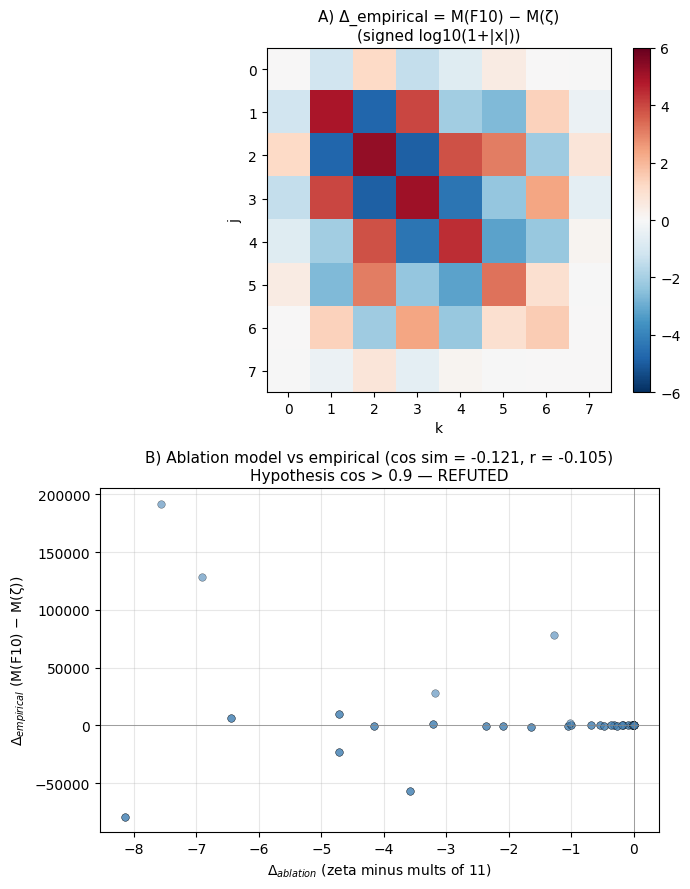

Cosine similarity: -0.12117153572794877
Pearson r: -0.10527795975290599


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Final figure: log-magnitude heatmaps of Delta_empirical and Delta_ablation, plus scatter showing cosine.
fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# Panel A: side by side heatmaps of |Delta_empirical| and |Delta_ablation| via log scale
ax = axes[0]
# Use signed log: sign * log10(1+|x|)
def signed_log(M):
 return np.sign(M) * np.log10(1 + np.abs(M))

im1 = ax.imshow(signed_log(Delta_empirical), cmap='RdBu_r', vmin=-6, vmax=6, aspect='equal')
ax.set_title("A) Δ_empirical = M(F10) − M(ζ)\n(signed log10(1+|x|))", fontsize=11)
ax.set_xlabel("k"); ax.set_ylabel("j")
ax.set_xticks(range(8)); ax.set_yticks(range(8))
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# Panel B: scatter of vectorized values 
ax = axes[1]
v_e = Delta_empirical.flatten()
v_a = Delta_ablation.flatten()
ax.scatter(v_a, v_e, alpha=0.6, s=30, color='steelblue', edgecolor='k', linewidth=0.3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(r"$\Delta_{ablation}$ (zeta minus mults of 11)")
ax.set_ylabel(r"$\Delta_{empirical}$ (M(F10) − M(ζ))")
ax.set_title(f"B) Ablation model vs empirical (cos sim = {cos_sim:.3f}, r = {r:.3f})\nHypothesis cos > 0.9 — REFUTED", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("F10_ablation_test.png", dpi=140, bbox_inches='tight')
plt.show()
print("Cosine similarity:", cos_sim)
print("Pearson r:", r)
